In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import time
import copy
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

Device: cuda


In [ ]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

def get_dataloaders(dataset_name="cifar10", batch_size=128, subset_fraction=1.0):
    if dataset_name == "cifar10":
        train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
        test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)
        num_classes = 10
    elif dataset_name == "cifar100":
        train_set = torchvision.datasets.CIFAR100(root="./data", train=True, download=True, transform=transform_train)
        test_set = torchvision.datasets.CIFAR100(root="./data", train=False, download=True, transform=transform_test)
        num_classes = 100
    else:
        raise ValueError("dataset_name must be 'cifar10' or 'cifar100'")

    if subset_fraction < 1.0:
        n_train = int(len(train_set) * subset_fraction)
        indices = list(range(len(train_set)))
        random.shuffle(indices)
        train_set = torch.utils.data.Subset(train_set, indices[:n_train])

    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, test_loader, num_classes

In [ ]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1, use_skip=True):
        super().__init__()
        self.use_skip = use_skip
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if use_skip and (stride != 1 or in_planes != planes * self.expansion):
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes * self.expansion, 1, stride, bias=False),
                nn.BatchNorm2d(planes * self.expansion)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.use_skip:
            out += self.shortcut(x)
        out = F.relu(out)
        return out

class Bottleneck(nn.Module):
    expansion = 4
    def __init__(self, in_planes, planes, stride=1, use_skip=True):
        super().__init__()
        self.use_skip = use_skip
        self.conv1 = nn.Conv2d(in_planes, planes, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, planes * self.expansion, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)
        self.shortcut = nn.Sequential()
        if use_skip and (stride != 1 or in_planes != planes * self.expansion):
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes * self.expansion, 1, stride, bias=False),
                nn.BatchNorm2d(planes * self.expansion)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        if self.use_skip:
            out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNetCIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10, use_bn=True, use_skip=True):
        super().__init__()
        self.in_planes = 64
        self.use_bn = use_bn
        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(64) if use_bn else nn.Identity()
        self.layer1 = self._make_layer(block, 64, num_blocks[0], 1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], 2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], 2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], 2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s, use_skip=self.use_skip))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

def ResNet18(num_classes=10, use_bn=True, use_skip=True):
    return ResNetCIFAR(BasicBlock, [2, 2, 2, 2], num_classes, use_bn, use_skip)

def ResNet34(num_classes=10, use_bn=True, use_skip=True):
    return ResNetCIFAR(BasicBlock, [3, 4, 6, 3], num_classes, use_bn, use_skip)

def ResNet50(num_classes=10, use_bn=True, use_skip=True):
    return ResNetCIFAR(Bottleneck, [3, 4, 6, 3], num_classes, use_bn, use_skip)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
def train_model(model, train_loader, test_loader, epochs=8, lr=0.01):
    model = model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    epoch_times = []
    for epoch in range(epochs):
        model.train()
        t0 = time.time()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        scheduler.step()
        t1 = time.time()
        epoch_times.append(t1 - t0)
        acc = evaluate(model, test_loader)
        print(f"  Epoch {epoch+1}/{epochs} - time: {t1-t0:.1f}s - test_acc: {acc:.4f}")

    avg_epoch_time = np.mean(epoch_times)
    final_acc = evaluate(model, test_loader)
    return model, final_acc, avg_epoch_time

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return correct / total

In [ ]:
EPOCHS = 8
SUBSET = 1.0

train_loader_10, test_loader_10, nc10 = get_dataloaders("cifar10", subset_fraction=SUBSET)

architectures = {
    "ResNet-18": ResNet18,
    "ResNet-34": ResNet34,
    "ResNet-50": ResNet50,
}

results_cifar10 = {}

for name, constructor in architectures.items():
    print(f"\nTraining {name} on CIFAR-10")
    set_seed(SEED)
    model = constructor(num_classes=nc10)
    n_params = count_parameters(model)
    trained_model, acc, avg_time = train_model(model, train_loader_10, test_loader_10, epochs=EPOCHS)
    results_cifar10[name] = {
        "test_accuracy": acc,
        "avg_epoch_time": avg_time,
        "num_params": n_params,
        "model": trained_model
    }
    print(f"{name}: acc={acc:.4f}, params={n_params:,}, avg_epoch_time={avg_time:.1f}s")

print("\nSummary (CIFAR-10)")
for name, r in results_cifar10.items():
    print(f"{name}: acc={r['test_accuracy']:.4f}, params={r['num_params']:,}, epoch_time={r['avg_epoch_time']:.1f}s")

100%|██████████| 170M/170M [25:40<00:00, 111kB/s]



Training ResNet-18 on CIFAR-10
  Epoch 1/8 - time: 39.7s - test_acc: 0.5752
  Epoch 2/8 - time: 40.0s - test_acc: 0.6579
  Epoch 3/8 - time: 44.3s - test_acc: 0.7480
  Epoch 4/8 - time: 44.3s - test_acc: 0.8055
  Epoch 5/8 - time: 44.2s - test_acc: 0.8331
  Epoch 6/8 - time: 44.1s - test_acc: 0.8438
  Epoch 7/8 - time: 44.0s - test_acc: 0.8648
  Epoch 8/8 - time: 44.2s - test_acc: 0.8735
ResNet-18: acc=0.8735, params=11,173,962, avg_epoch_time=43.1s

Training ResNet-34 on CIFAR-10
  Epoch 1/8 - time: 75.4s - test_acc: 0.5595
  Epoch 2/8 - time: 75.0s - test_acc: 0.6729
  Epoch 3/8 - time: 75.8s - test_acc: 0.6731
  Epoch 4/8 - time: 75.3s - test_acc: 0.7950
  Epoch 5/8 - time: 76.0s - test_acc: 0.8180
  Epoch 6/8 - time: 75.7s - test_acc: 0.8465
  Epoch 7/8 - time: 75.7s - test_acc: 0.8699
  Epoch 8/8 - time: 75.9s - test_acc: 0.8785
ResNet-34: acc=0.8785, params=21,282,122, avg_epoch_time=75.6s

Training ResNet-50 on CIFAR-10
  Epoch 1/8 - time: 173.0s - test_acc: 0.4813
  Epoch 2/8 

In [ ]:
train_loader_100, test_loader_100, nc100 = get_dataloaders("cifar100", subset_fraction=SUBSET)

results_cifar100 = {}

for name, constructor in architectures.items():
    print(f"\nTraining {name} on CIFAR-100")
    set_seed(SEED)
    model = constructor(num_classes=nc100)
    n_params = count_parameters(model)
    trained_model, acc, avg_time = train_model(model, train_loader_100, test_loader_100, epochs=EPOCHS)
    results_cifar100[name] = {
        "test_accuracy": acc,
        "avg_epoch_time": avg_time,
        "num_params": n_params,
        "model": trained_model
    }
    print(f"{name}: acc={acc:.4f}, params={n_params:,}, avg_epoch_time={avg_time:.1f}s")

print("\nSummary (CIFAR-100)")
for name, r in results_cifar100.items():
    print(f"{name}: acc={r['test_accuracy']:.4f}, params={r['num_params']:,}, epoch_time={r['avg_epoch_time']:.1f}s")

100%|██████████| 169M/169M [19:35<00:00, 144kB/s]



Training ResNet-18 on CIFAR-100
  Epoch 1/8 - time: 46.0s - test_acc: 0.2145
  Epoch 2/8 - time: 43.2s - test_acc: 0.3271
  Epoch 3/8 - time: 44.3s - test_acc: 0.3806
  Epoch 4/8 - time: 44.3s - test_acc: 0.4569
  Epoch 5/8 - time: 44.1s - test_acc: 0.5017
  Epoch 6/8 - time: 44.2s - test_acc: 0.5524
  Epoch 7/8 - time: 44.5s - test_acc: 0.5872
  Epoch 8/8 - time: 44.2s - test_acc: 0.6064
ResNet-18: acc=0.6064, params=11,220,132, avg_epoch_time=44.4s

Training ResNet-34 on CIFAR-100
  Epoch 1/8 - time: 75.1s - test_acc: 0.1846
  Epoch 2/8 - time: 75.8s - test_acc: 0.2610
  Epoch 3/8 - time: 75.4s - test_acc: 0.3382
  Epoch 4/8 - time: 75.6s - test_acc: 0.3770
  Epoch 5/8 - time: 75.5s - test_acc: 0.4666
  Epoch 6/8 - time: 75.2s - test_acc: 0.5259
  Epoch 7/8 - time: 75.9s - test_acc: 0.5764
  Epoch 8/8 - time: 75.5s - test_acc: 0.5984
ResNet-34: acc=0.5984, params=21,328,292, avg_epoch_time=75.5s

Training ResNet-50 on CIFAR-100
  Epoch 1/8 - time: 172.6s - test_acc: 0.1355
  Epoch 2

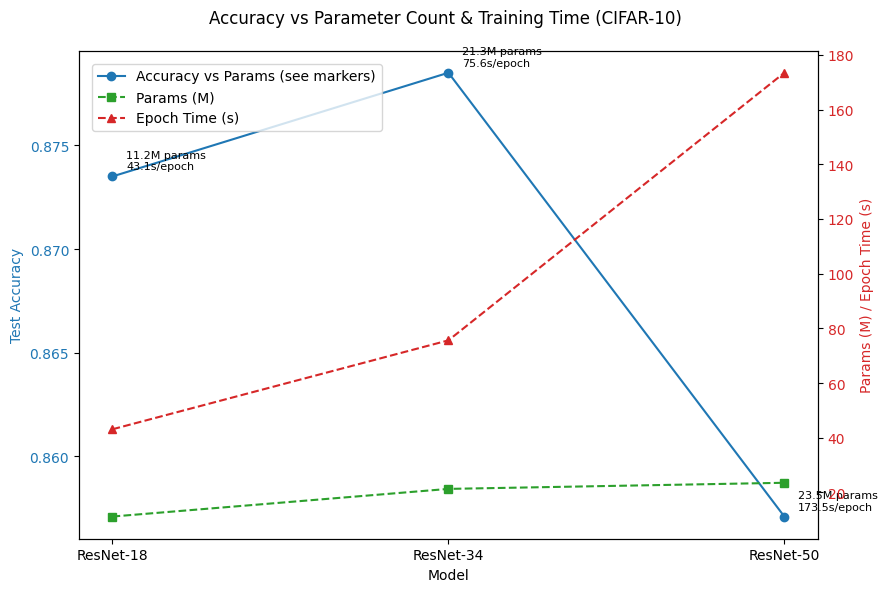


CIFAR-10 vs CIFAR-100 comparison:
ResNet-18: CIFAR-10 acc=0.8735 | CIFAR-100 acc=0.6064
ResNet-34: CIFAR-10 acc=0.8785 | CIFAR-100 acc=0.5984
ResNet-50: CIFAR-10 acc=0.8571 | CIFAR-100 acc=0.5386


In [ ]:
names = list(results_cifar10.keys())
params = [results_cifar10[n]["num_params"] / 1e6 for n in names]
accs = [results_cifar10[n]["test_accuracy"] for n in names]
times = [results_cifar10[n]["avg_epoch_time"] for n in names]

fig, ax1 = plt.subplots(figsize=(9, 6))

color1 = "tab:blue"
ax1.set_xlabel("Model")
ax1.set_ylabel("Test Accuracy", color=color1)
ax1.plot(names, accs, "o-", color=color1, label="Accuracy vs Params (see markers)")
ax1.tick_params(axis="y", labelcolor=color1)

for i, n in enumerate(names):
    ax1.annotate(f"{params[i]:.1f}M params\n{times[i]:.1f}s/epoch", (n, accs[i]),
                 textcoords="offset points", xytext=(10, 5), fontsize=8)

ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("Params (M) / Epoch Time (s)", color=color2)
ax2.plot(names, params, "s--", color="tab:green", label="Params (M)")
ax2.plot(names, times, "^--", color=color2, label="Epoch Time (s)")
ax2.tick_params(axis="y", labelcolor=color2)

fig.suptitle("Accuracy vs Parameter Count & Training Time (CIFAR-10)")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

# مقایسه CIFAR-10 در برابر CIFAR-100
print("\nCIFAR-10 vs CIFAR-100 comparison:")
for name in names:
    print(f"{name}: CIFAR-10 acc={results_cifar10[name]['test_accuracy']:.4f} | "
          f"CIFAR-100 acc={results_cifar100[name]['test_accuracy']:.4f}")


LMC experiment: BN + Skip (BN=True, Skip=True)
  Epoch 1/6 - time: 27.4s - test_acc: 0.5401
  Epoch 2/6 - time: 28.0s - test_acc: 0.6208
  Epoch 3/6 - time: 26.8s - test_acc: 0.6900
  Epoch 4/6 - time: 27.1s - test_acc: 0.7779
  Epoch 5/6 - time: 27.1s - test_acc: 0.8026
  Epoch 6/6 - time: 26.9s - test_acc: 0.8222
  Epoch 1/6 - time: 27.1s - test_acc: 0.5795
  Epoch 2/6 - time: 26.9s - test_acc: 0.6629
  Epoch 3/6 - time: 26.9s - test_acc: 0.7291
  Epoch 4/6 - time: 27.2s - test_acc: 0.7712
  Epoch 5/6 - time: 26.9s - test_acc: 0.7737
  Epoch 6/6 - time: 27.0s - test_acc: 0.8273
Model A acc=0.8222, Model B acc=0.8273
  alpha=0.00 -> acc=0.8222
  alpha=0.10 -> acc=0.6663
  alpha=0.20 -> acc=0.2464
  alpha=0.30 -> acc=0.1079
  alpha=0.40 -> acc=0.1001
  alpha=0.50 -> acc=0.1000
  alpha=0.60 -> acc=0.1049
  alpha=0.70 -> acc=0.1342
  alpha=0.80 -> acc=0.2347
  alpha=0.90 -> acc=0.6391
  alpha=1.00 -> acc=0.8273

LMC experiment: BN, No Skip (BN=True, Skip=False)
  Epoch 1/6 - time: 24.9s

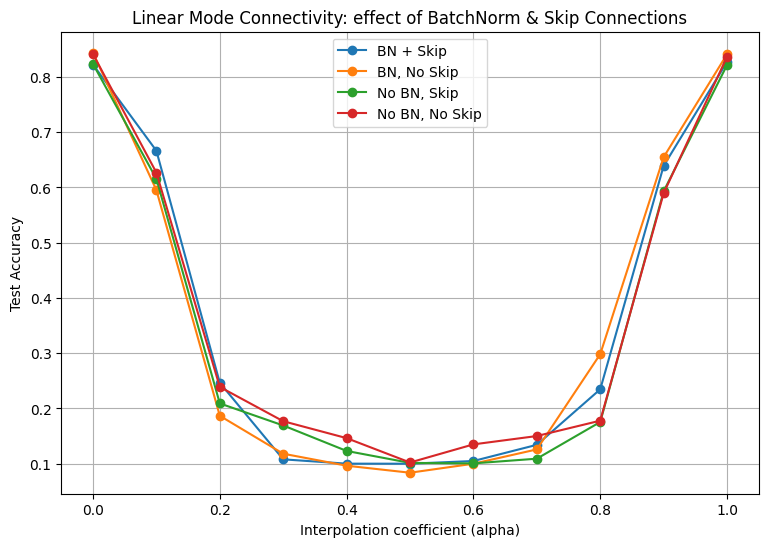

In [ ]:
def make_small_cnn(num_classes=10, use_bn=True, use_skip=True):
    return ResNetCIFAR(BasicBlock, [1, 1, 1, 1], num_classes=num_classes, use_bn=use_bn, use_skip=use_skip)

def interpolate_and_evaluate(model_a, model_b, test_loader, num_classes, use_bn, use_skip, n_points=11):
    state_a = model_a.state_dict()
    state_b = model_b.state_dict()
    alphas = np.linspace(0, 1, n_points)
    accs = []
    for alpha in alphas:
        interp_model = make_small_cnn(num_classes, use_bn, use_skip).to(device)
        interp_state = {}
        for key in state_a:
            interp_state[key] = (1 - alpha) * state_a[key] + alpha * state_b[key]
        interp_model.load_state_dict(interp_state)
        acc = evaluate(interp_model, test_loader)
        accs.append(acc)
        print(f"  alpha={alpha:.2f} -> acc={acc:.4f}")
    return alphas, accs

def run_lmc_experiment(use_bn, use_skip, label, epochs=6):
    print(f"\nLMC experiment: {label} (BN={use_bn}, Skip={use_skip})")
    set_seed(1)
    model_a = make_small_cnn(nc10, use_bn, use_skip)
    model_a, acc_a, _ = train_model(model_a, train_loader_10, test_loader_10, epochs=epochs)

    set_seed(2)
    model_b = make_small_cnn(nc10, use_bn, use_skip)
    model_b, acc_b, _ = train_model(model_b, train_loader_10, test_loader_10, epochs=epochs)

    print(f"Model A acc={acc_a:.4f}, Model B acc={acc_b:.4f}")
    alphas, accs = interpolate_and_evaluate(model_a, model_b, test_loader_10, nc10, use_bn, use_skip)
    return alphas, accs

configs = [
    (True, True, "BN + Skip"),
    (True, False, "BN, No Skip"),
    (False, True, "No BN, Skip"),
    (False, False, "No BN, No Skip"),
]

lmc_results = {}
for use_bn, use_skip, label in configs:
    alphas, accs = run_lmc_experiment(use_bn, use_skip, label)
    lmc_results[label] = (alphas, accs)

plt.figure(figsize=(9, 6))
for label, (alphas, accs) in lmc_results.items():
    plt.plot(alphas, accs, "o-", label=label)
plt.xlabel("Interpolation coefficient (alpha)")
plt.ylabel("Test Accuracy")
plt.title("Linear Mode Connectivity: effect of BatchNorm & Skip Connections")
plt.legend()
plt.grid(True)
plt.show()

Best model: ResNet-34


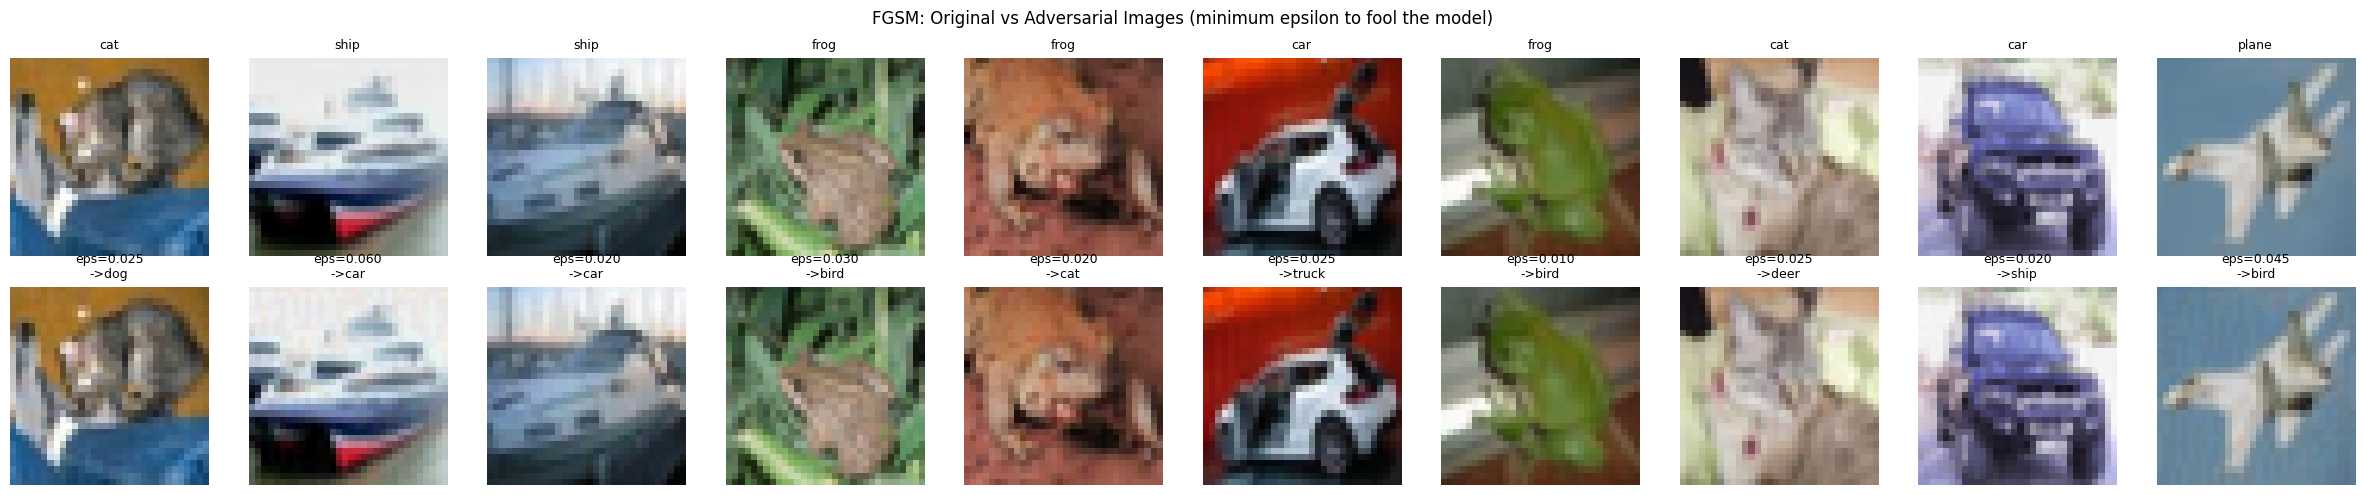


FGSM results per image:
{'true_label': 3, 'min_epsilon': 0.025, 'adv_pred': 5}
{'true_label': 8, 'min_epsilon': 0.05999999999999999, 'adv_pred': 1}
{'true_label': 8, 'min_epsilon': 0.02, 'adv_pred': 1}
{'true_label': 6, 'min_epsilon': 0.030000000000000002, 'adv_pred': 2}
{'true_label': 6, 'min_epsilon': 0.02, 'adv_pred': 3}
{'true_label': 1, 'min_epsilon': 0.025, 'adv_pred': 9}
{'true_label': 6, 'min_epsilon': 0.01, 'adv_pred': 2}
{'true_label': 3, 'min_epsilon': 0.025, 'adv_pred': 4}
{'true_label': 1, 'min_epsilon': 0.02, 'adv_pred': 8}
{'true_label': 0, 'min_epsilon': 0.045, 'adv_pred': 2}


In [ ]:
best_model_name = max(results_cifar10, key=lambda n: results_cifar10[n]["test_accuracy"])
best_model = results_cifar10[best_model_name]["model"]
best_model.eval()
print(f"Best model: {best_model_name}")

cifar10_classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(1, 3, 1, 1).to(device)
std = torch.tensor((0.2470, 0.2435, 0.2616)).view(1, 3, 1, 1).to(device)

def denormalize(x):
    return (x * std + mean).clamp(0, 1)

def fgsm_attack(model, image, label, epsilon):
    image = image.clone().detach().to(device).requires_grad_(True)
    label = label.to(device)
    output = model(image)
    loss = F.cross_entropy(output, label)
    model.zero_grad()
    loss.backward()
    perturbed = image + epsilon * image.grad.sign()
    perturbed = perturbed.detach()
    return perturbed

def find_min_epsilon(model, image, label, eps_max=0.3, eps_step=0.005):
    eps = 0.0
    orig_pred = model(image.to(device)).argmax(1).item()
    while eps <= eps_max:
        adv = fgsm_attack(model, image, label, eps)
        pred = model(adv).argmax(1).item()
        if pred != orig_pred:
            return eps, adv, pred
        eps += eps_step
    return None, adv, pred

correct_samples = []
best_model.to(device)
with torch.no_grad():
    for inputs, labels in test_loader_10:
        inputs, labels = inputs.to(device), labels.to(device)
        preds = best_model(inputs).argmax(1)
        for i in range(inputs.size(0)):
            if preds[i] == labels[i]:
                correct_samples.append((inputs[i:i+1].cpu(), labels[i:i+1].cpu()))
            if len(correct_samples) >= 10:
                break
        if len(correct_samples) >= 10:
            break

fgsm_results = []
fig, axes = plt.subplots(2, 10, figsize=(24, 5))
for idx, (img, label) in enumerate(correct_samples):
    min_eps, adv_img, adv_pred = find_min_epsilon(best_model, img, label)
    fgsm_results.append({
        "true_label": label.item(),
        "min_epsilon": min_eps,
        "adv_pred": adv_pred
    })

    orig_display = denormalize(img.to(device)).squeeze().permute(1, 2, 0).cpu().numpy()
    adv_display = denormalize(adv_img).squeeze().permute(1, 2, 0).cpu().numpy()

    axes[0, idx].imshow(orig_display)
    axes[0, idx].set_title(f"{cifar10_classes[label.item()]}", fontsize=9)
    axes[0, idx].axis("off")

    axes[1, idx].imshow(adv_display)
    eps_str = f"{min_eps:.3f}" if min_eps is not None else ">0.3"
    axes[1, idx].set_title(f"eps={eps_str}\n->{cifar10_classes[adv_pred]}", fontsize=9)
    axes[1, idx].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Adversarial", fontsize=10)
plt.suptitle("FGSM: Original vs Adversarial Images (minimum epsilon to fool the model)")
plt.tight_layout()
plt.show()

print("\nFGSM results per image:")
for r in fgsm_results:
    print(r)

Per-class robust accuracy under FGSM (eps=0.03):
  plane: 0.3320
  car: 0.5440
  bird: 0.2430
  cat: 0.1260
  deer: 0.2350
  dog: 0.2260
  frog: 0.2540
  horse: 0.3030
  ship: 0.6080
  truck: 0.4870


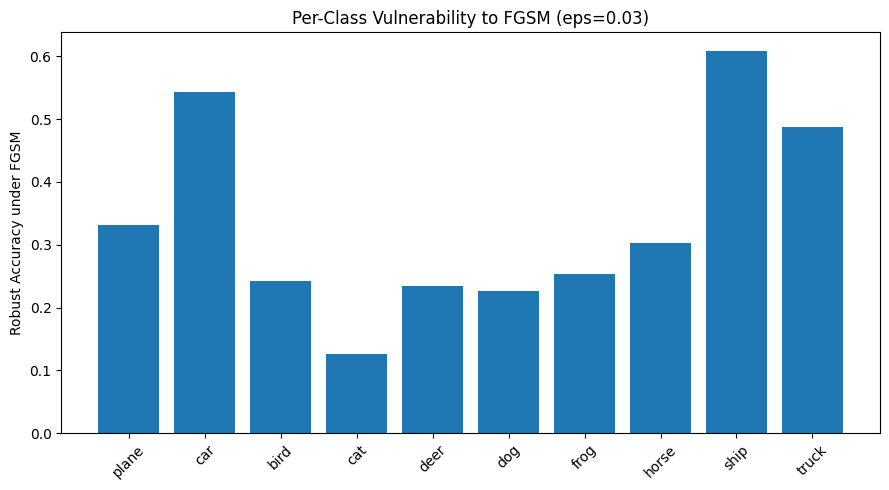


Training a robust model with Adversarial Training
  [AdvTrain] Epoch 1/8 - time: 135.1s - clean_acc: 0.5184
  [AdvTrain] Epoch 2/8 - time: 133.6s - clean_acc: 0.6203
  [AdvTrain] Epoch 3/8 - time: 134.9s - clean_acc: 0.7054
  [AdvTrain] Epoch 4/8 - time: 135.5s - clean_acc: 0.7481
  [AdvTrain] Epoch 5/8 - time: 134.2s - clean_acc: 0.7744
  [AdvTrain] Epoch 6/8 - time: 134.4s - clean_acc: 0.7958
  [AdvTrain] Epoch 7/8 - time: 134.4s - clean_acc: 0.8105
  [AdvTrain] Epoch 8/8 - time: 135.6s - clean_acc: 0.8277

Robustness Comparison
Original model  -> clean_acc=0.8785, robust_acc(eps=0.03)=0.3358
Adv-trained model -> clean_acc=0.8277, robust_acc(eps=0.03)=0.6609

Robustness improvement: 32.51 percentage points


In [ ]:
fixed_eps = 0.03
class_correct = {c: 0 for c in range(nc10)}
class_total = {c: 0 for c in range(nc10)}

best_model.eval()
for inputs, labels in test_loader_10:
    inputs, labels = inputs.to(device), labels.to(device)
    inputs.requires_grad = True
    outputs = best_model(inputs)
    loss = F.cross_entropy(outputs, labels)
    best_model.zero_grad()
    loss.backward()
    adv_inputs = (inputs + fixed_eps * inputs.grad.sign()).detach()
    adv_preds = best_model(adv_inputs).argmax(1)
    for i in range(labels.size(0)):
        c = labels[i].item()
        class_total[c] += 1
        if adv_preds[i] == labels[i]:
            class_correct[c] += 1

print(f"Per-class robust accuracy under FGSM (eps={fixed_eps}):")
class_robust_acc = {}
for c in range(nc10):
    acc = class_correct[c] / class_total[c]
    class_robust_acc[c] = acc
    print(f"  {cifar10_classes[c]}: {acc:.4f}")

plt.figure(figsize=(9, 5))
plt.bar([cifar10_classes[c] for c in range(nc10)], [class_robust_acc[c] for c in range(nc10)])
plt.ylabel("Robust Accuracy under FGSM")
plt.title(f"Per-Class Vulnerability to FGSM (eps={fixed_eps})")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

def adversarial_train_model(model, train_loader, test_loader, epochs=8, lr=0.01, eps=0.03):
    model = model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        t0 = time.time()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            inputs.requires_grad = True
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            model.zero_grad()
            loss.backward()
            adv_inputs = (inputs + eps * inputs.grad.sign()).detach()

            optimizer.zero_grad()
            clean_out = model(inputs.detach())
            adv_out = model(adv_inputs)
            total_loss = 0.5 * criterion(clean_out, labels) + 0.5 * criterion(adv_out, labels)
            total_loss.backward()
            optimizer.step()
        scheduler.step()
        acc = evaluate(model, test_loader)
        print(f"  [AdvTrain] Epoch {epoch+1}/{epochs} - time: {time.time()-t0:.1f}s - clean_acc: {acc:.4f}")

    return model

print("\nTraining a robust model with Adversarial Training")
set_seed(SEED)
robust_model = ResNet18(num_classes=nc10).to(device)
robust_model = adversarial_train_model(robust_model, train_loader_10, test_loader_10, epochs=EPOCHS, eps=fixed_eps)

clean_acc_robust = evaluate(robust_model, test_loader_10)

def eval_robust_accuracy(model, loader, eps):
    model.eval()
    correct, total = 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        inputs.requires_grad = True
        outputs = model(inputs)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()
        adv_inputs = (inputs + eps * inputs.grad.sign()).detach()
        preds = model(adv_inputs).argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total

robust_acc_before = eval_robust_accuracy(best_model, test_loader_10, fixed_eps)
robust_acc_after = eval_robust_accuracy(robust_model, test_loader_10, fixed_eps)

print("\nRobustness Comparison")
print(f"Original model  -> clean_acc={results_cifar10[best_model_name]['test_accuracy']:.4f}, "
      f"robust_acc(eps={fixed_eps})={robust_acc_before:.4f}")
print(f"Adv-trained model -> clean_acc={clean_acc_robust:.4f}, "
      f"robust_acc(eps={fixed_eps})={robust_acc_after:.4f}")
print(f"\nRobustness improvement: {(robust_acc_after - robust_acc_before)*100:.2f} percentage points")